# Exploratory Data Analysis (EDA)

## Objective

This analysis examines a cleaned customer survey dataset collected to understand demographic profiles, purchasing behavior, product preferences, and satisfaction levels across multiple market segments


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/survey_cleaned.csv')

sns.set_theme(style='whitegrid', palette='muted')

print('Shape:', df.shape)
df.head()

Shape: (500, 19)


,respondent_id,age,gender,region,occupation,education_level,monthly_income_birr,visits_per_month,avg_spend_per_visit_birr,satisfaction_score,preferred_product_category,purchase_channel,top_challenge,true_segment,log_monthly_income_birr,monthly_spend_birr,spend_norm,sat_norm,customer_value_score
0,R0001,36.0,female,amhara,private employee,secondary,9751.0,3,1949.0,4.0,health & beauty,physical shop,price too high,B,9.185228,5847.0,0.265672,0.8,0.479403
1,R0002,38.0,female,snnpr,daily laborer,no formal education,2731.0,4,426.0,3.0,mobile top-up & airtime,word of mouth,inconvenient location,C,7.912789,1704.0,0.073715,0.6,0.284229
2,R0003,31.0,female,addis ababa,self-employed / trader,diploma,8247.0,7,1063.0,2.0,food & groceries,word of mouth,poor customer service,B,9.017726,7441.0,0.339526,0.4,0.363716
3,R0004,41.0,male,oromia,private employee,bachelor's+,8915.0,6,1094.0,3.0,food & groceries,word of mouth,price too high,B,9.095603,6564.0,0.298893,0.6,0.419336
4,R0005,20.0,female,addis ababa,student,bachelor's+,5049.0,7,544.0,3.0,clothing & fashion,social media (tiktok/instagram),price too high,A,8.527144,3808.0,0.171200,0.6,0.342720


## 1. Respondents by Region

**Analysis Purpose:** Quantify the geographic distribution of survey respondents to assess market coverage and identify regions with the strongest customer presence.

**Why This Visualization:** A bar chart enables direct count comparison across categorical regions, making rank-order differences immediately visible to stakeholders.


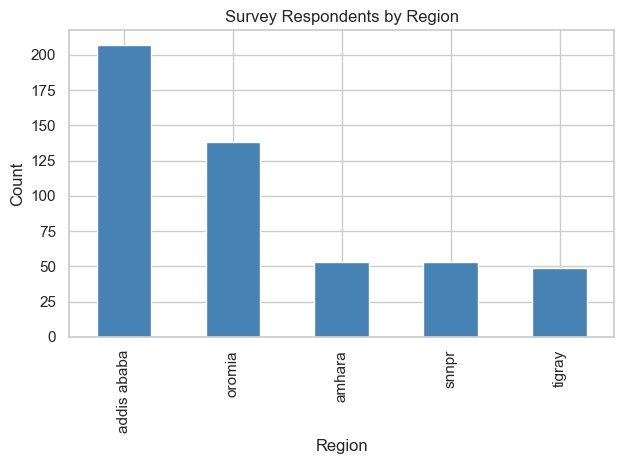

In [ ]:
df['region'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Survey Respondents by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/01_respondents_by_region.png', dpi=150)
plt.show()

**Key Insight:** Addis Ababa records the highest respondent concentration, confirming it as the dominant market footprint in this dataset; regions with materially lower counts are underrepresented and may introduce geographic bias into downstream analysis.


### Key Insight

- Addis Ababa records the highest respondent concentration.
- Several regions have significantly lower representation.
- Geographic imbalance may affect the generalizability of findings.

### Business Impact

Overrepresentation from one region may lead to strategies that perform well locally but fail in other markets.

### Recommendation

- Increase data collection efforts in underrepresented regions.
- Consider weighting responses by regional population share.


## 2. Income Distribution


### Analysis Purpose

Understand the income profile of respondents and evaluate purchasing power across the customer base.

### Why This Visualization

Histograms reveal distribution shape, skewness, concentration, and outliers.


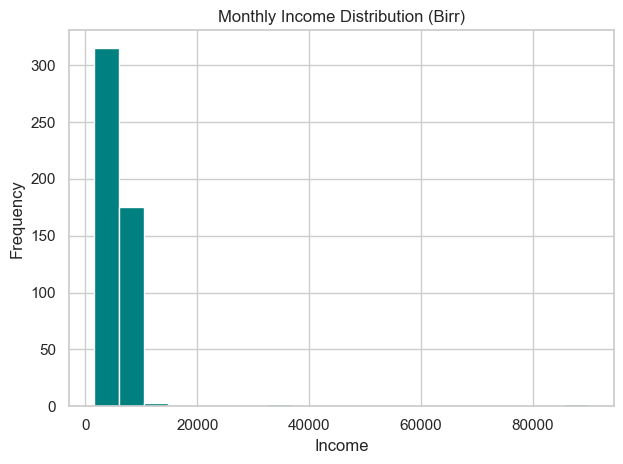

In [ ]:
df['monthly_income_birr'].hist(bins=20, color='teal', edgecolor='white')
plt.title('Monthly Income Distribution (Birr)')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../charts/02_income_distribution.png', dpi=150)
plt.show()

### Key Insight

- Income distribution is right-skewed.
- Most respondents fall within lower-to-middle income ranges.
- A smaller high-income segment exists.

### Business Impact

Different income groups may require different pricing and promotional strategies.

### Recommendation

Create separate customer segments:

1. Low-income customers
2. Middle-income customers
3. High-income customers


## 3. Average Spend by Occupation

**Purpose:** Compare spending behavior across occupational groups.


### Why This Visualization

A sorted horizontal bar chart makes comparisons easy and highlights top-spending occupations.


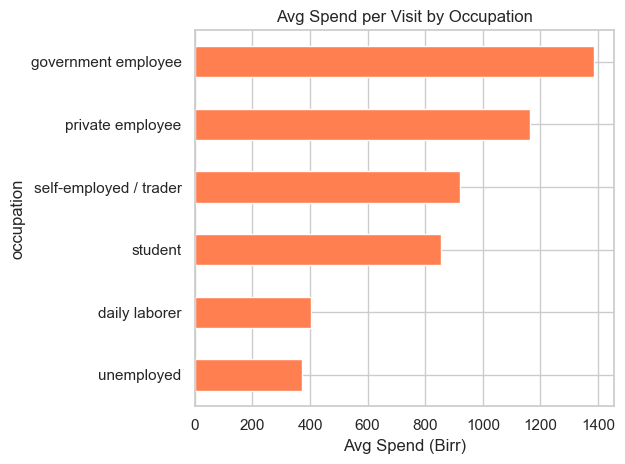

In [ ]:
df.groupby('occupation')['avg_spend_per_visit_birr'].mean(
).sort_values().plot(kind='barh', color='coral')
plt.title('Avg Spend per Visit by Occupation')
plt.xlabel('Avg Spend (Birr)')
plt.tight_layout()
plt.savefig('../charts/03_spend_by_occupation.png', dpi=150)
plt.show()

### Key Insight

- Professionals and business owners spend more on average.
- Students generally spend less.
- Spending patterns appear linked to earning potential.

### Business Impact

High-spending occupations may provide greater return on targeted marketing investment.

### Recommendation

Develop customer profiles that combine:

- Occupation
- Income
- Satisfaction score
- Spending behavior


## 4. Preferred Product Categories

**Purpose:** Identify the products most frequently preferred by customers.and use it to guide inventory planning and marketing prioritization.


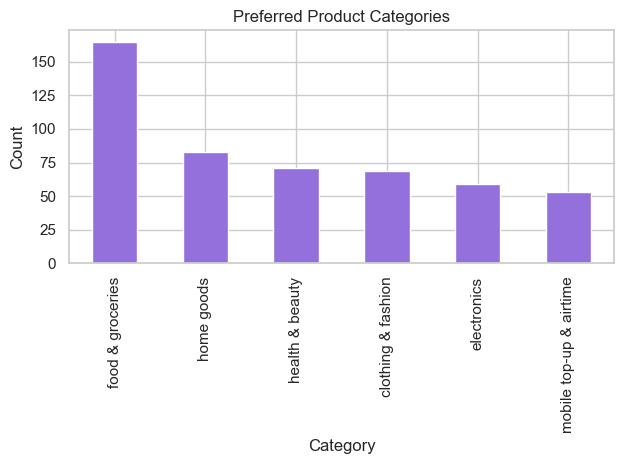

In [ ]:
df['preferred_product_category'].value_counts().plot(
    kind='bar', color='mediumpurple')
plt.title('Preferred Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/04_preferred_products.png', dpi=150)
plt.show()

**Key Insight:** The top one categorie capture a disproportionate share of stated preferences, suggesting concentrated demand; low-frequency categories may suffer from limited awareness rather than actual low interest

**Business Impact:** Misaligned inventory — stocking underperforming categories at the expense of high-demand ones — directly erodes revenue and customer satisfaction.

**Recommendation:** Reallocate promotional budget toward the top two categories while A/B testing awareness campaigns for lower-frequency categories to assess whether demand is latent or absent.


## 5. Purchase Channels


**Analysis Purpose:** Quantify the relative share of each customer acquisition and purchase channel to guide omnichannel investment decisions.

**Why This Visualization:** A pie chart with percentage labels communicates share-of-total at a glance, making it appropriate for executive-level channel mix reporting.


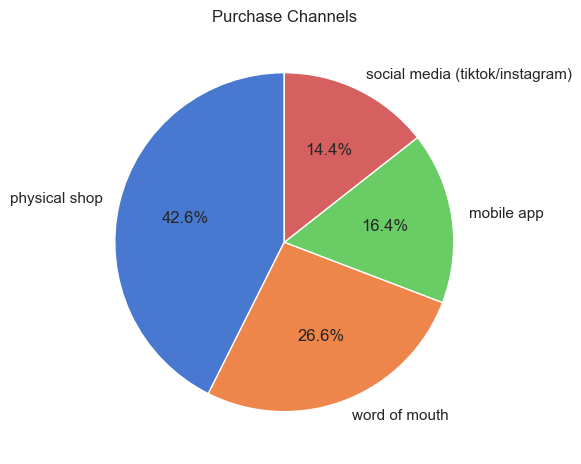

In [ ]:
df['purchase_channel'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Purchase Channels')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../charts/05_purchase_channels.png', dpi=150)
plt.show()

**Key Insight:** Physical shop dominates at 42.6% — the single largest channel by a wide margin — while word of mouth (26.6%) emerges as a surprisingly strong second channel, indicating that peer referral is a significant organic acquisition driver. Mobile app (16.4%) and social media via TikTok/Instagram (14.4%) together account for 30.8% of engagement, signaling meaningful but not yet dominant digital adoption.

**Business Impact:** With over 57% of customer engagement coming through non-digital channels (physical shop and word of mouth), an aggressive digital-first strategy without maintaining in-store and referral experience risks alienating the majority of the current customer base.

**Recommendation:** Invest in a structured referral incentive program to formalize and amplify the existing 26.6% word-of-mouth channel, while gradually scaling mobile app investment to convert the digitally engaged 30.8% into a higher-value retention cohort.


## 6. Satisfaction Scores


**Analysis Purpose:** Measure the distribution of customer satisfaction to quantify the size of the at-risk customer segment and assess overall experience performance.

**Why This Visualization:** A count plot on an ordinal 1–5 scale captures both the distribution shape and the relative frequency of each sentiment tier, making dissatisfaction clusters immediately visible alongside the satisfaction majority.


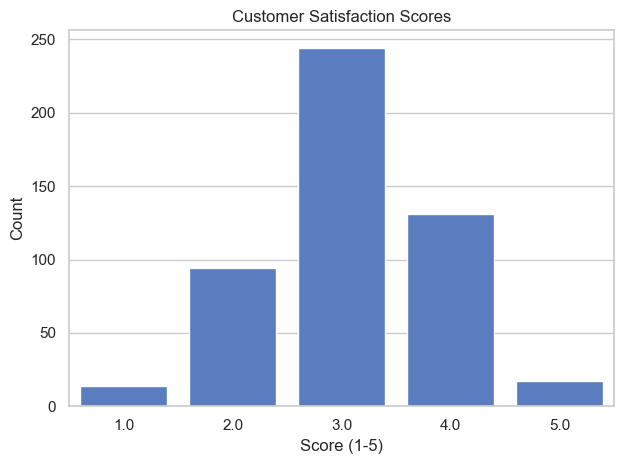

In [ ]:
sns.countplot(data=df, x='satisfaction_score')
plt.title('Customer Satisfaction Scores')
plt.xlabel('Score (1-5)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/06_satisfaction_scores.png', dpi=150)
plt.show()

**Key Insight:** Score 3 is by far the most common response at approximately 245 respondents, indicating that the majority of customers are neutrally satisfied rather than genuinely delighted — a fragile position. Score 4 (~130) and score 2 (~95) form the secondary tiers, while scores 1 (~14) and 5 (~18) are nearly symmetric at the extremes. Combined, scores 1 and 2 account for roughly 109 respondents — approximately 22% of the sample — representing a significant at-risk churn population.

**Business Impact:** A satisfaction base concentrated at score 3 means the business is one negative experience away from pushing a large segment into the dissatisfied tier; there is no loyalty buffer protecting against competitor switching.

**Recommendation:** Investigate the specific drivers of scores 1 and 2 — cross-referencing with the top challenges analysis — and design a targeted recovery campaign for this ~22% at-risk segment before churn materializes.


## 7. Correlation Heatmap

**Analysis Purpose:** Identify which variables most strongly drive customer spending and value.

**Why This Visualization:** An annotated heatmap delivers the full pairwise relationship matrix in one view, eliminating the need for individual scatter plots at the exploratory stage.


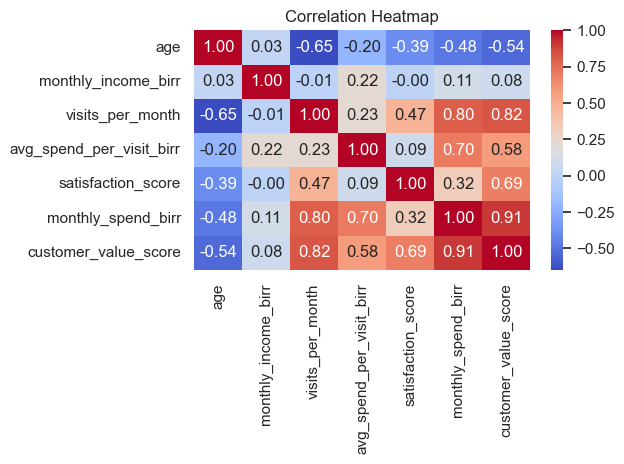

In [ ]:
num_cols = ['age', 'monthly_income_birr', 'visits_per_month',
            'avg_spend_per_visit_birr', 'satisfaction_score',
            'monthly_spend_birr', 'customer_value_score']

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../charts/07_correlation_heatmap.png', dpi=150)
plt.show()

**Key Insight:** `monthly_spend_birr` and `customer_value_score` correlate at **r = 0.91** — spend is the dominant value driver. `visits_per_month` strongly predicts both spend (r = 0.80) and value (r = 0.82), making it the most actionable behavioral lever. Critically, `monthly_income_birr` shows near-zero correlation with spend (r = 0.11) and value (r = 0.08) — income does not predict who spends. Age correlates negatively with visits (r = −0.65), confirming younger customers are significantly more frequent buyers.

**Business Impact:** Income-based targeting will systematically misidentify high-value customers; visit frequency is a far more reliable segmentation signal.

**Recommendation:** Replace income as the primary CRM targeting variable with a visit-frequency and spend composite score.


## 8. Income vs Monthly Spend


**Analysis Purpose:** Test whether income predicts monthly spending and whether geography modifies that relationship.

**Why This Visualization:** A regional scatter plot exposes the income–spend relationship, its dispersion, and geographic clustering in one view.


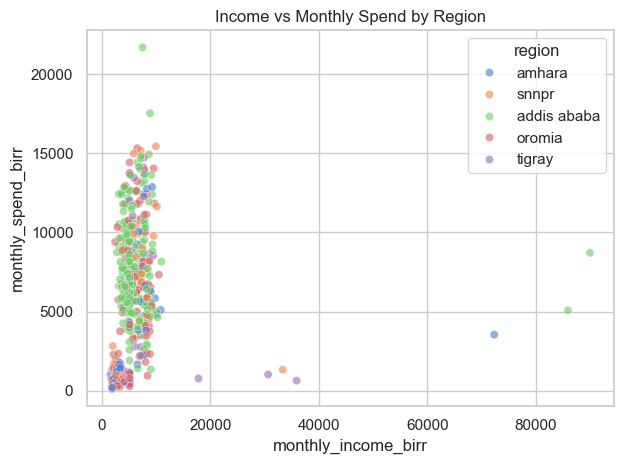

In [ ]:
sns.scatterplot(data=df, x='monthly_income_birr',
                y='monthly_spend_birr', hue='region', alpha=0.6)

plt.title('Income vs Monthly Spend by Region')
plt.tight_layout()
plt.savefig('../charts/08_income_vs_spend.png', dpi=150)
plt.show()

**Key Insight:** Nearly all respondents cluster densely below 10,000 Birr income, yet monthly spend within that cluster ranges widely from near-zero to ~22,000 Birr — confirming that income does not determine spending behavior for the mass market. High-income outliers at 70,000–90,000 Birr actually spend less (5,000–9,000 Birr) than several low-income respondents, reinforcing the r = 0.11 correlation finding. Addis Ababa (green) dominates the dense cluster at all spend levels.

**Business Impact:** Customers with high spend potential are distributed across income levels and invisible to income-based filters — they can only be found through behavioral data.

**Recommendation:** Segment customers on the spend–frequency axis using K-Means clustering rather than income brackets.


### Senior Analyst Interpretation

- The scatterplot helps identify high-value customer clusters.
- Customers with both high income and high spending are strategically important.
- Regional coloring may reveal geographic differences in purchasing behavior.

### Business Implication

Businesses can design targeted campaigns for high-income, high-spending segments.


## 9. Top Customer Challenges


**Analysis Purpose:** Prioritize customer pain points by frequency to direct operational improvement where it has the broadest impact.

**Why This Visualization:** A frequency bar chart functions as an implicit Pareto, surfacing the highest-impact problems first.


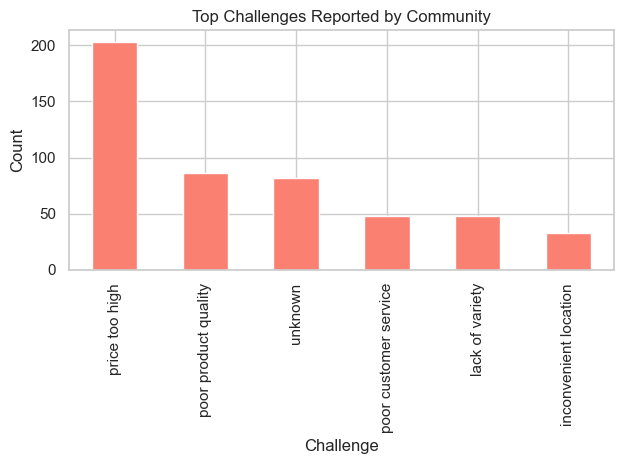

In [ ]:
df['top_challenge'].value_counts().plot(kind='bar', color='salmon')
plt.title('Top Challenges Reported by Community')
plt.xlabel('Challenge')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/09_top_challenges.png', dpi=150)
plt.show()

**Key Insight:** "Price too high" at ~202 mentions accounts for an estimated 40%+ of all challenge responses — more than double the second-ranked issue, poor product quality (~86). Poor customer service (~48) and lack of variety (~47) are nearly tied in third. The ~82 "unknown" responses represent a data collection gap that should be resolved before the next survey cycle.

**Business Impact:** When 40% of customers name price as their top barrier, the business is losing transactions to affordability friction rather than to competitor preference — a more controllable problem.

**Recommendation:** Introduce tiered or bundle pricing to directly address price sensitivity, and establish a product quality feedback loop to tackle the second-ranked issue before it grows.


## 10. Customer Value Score by Education Level

**Purpose:** Compare customer value across education groups.


**Analysis Purpose:** Assess whether education level differentiates customer value enough to serve as a targeting variable.

**Why This Visualization:** Boxplots expose median, spread, and outliers across groups simultaneously — capturing what group averages obscure.


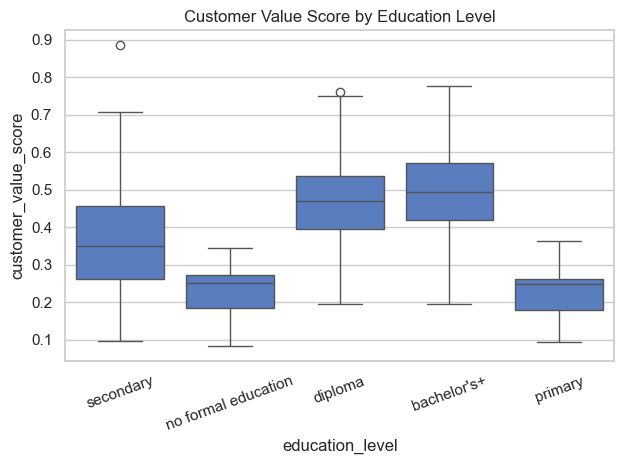

In [ ]:
sns.boxplot(data=df, x='education_level',
            y='customer_value_score')

plt.title('Customer Value Score by Education Level')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../charts/10_value_by_education.png', dpi=150)
plt.show()

**Key Insight:** Bachelor's+ holders have the highest median value score at ~0.50, followed by diploma holders at ~0.48. No-formal-education and primary groups both sit at ~0.22 — less than half the value of the top two groups. Secondary-educated customers show the widest range, with a high-value outlier near 0.88, indicating that this group is the most behaviorally heterogeneous and cannot be treated as a single segment.

**Business Impact:** Bachelor's+ and diploma holders deliver nearly 2× the customer value of the lowest education groups, making education a cost-effective filter for identifying premium segment candidates.

**Recommendation:** Enroll bachelor's+ and diploma holders as the primary target for loyalty program recruitment; investigate the secondary-educated outliers separately to identify what drives their above-average value.


## Income vs Spending ( Regression Trend Line)


**Analysis Purpose:** Quantify the directional relationship between customer income and monthly spending using a fitted trend line.

**Why This Visualization:** A regression plot isolates the overall trend from individual data points, making the income–spend relationship interpretable even where raw scatter is dense.


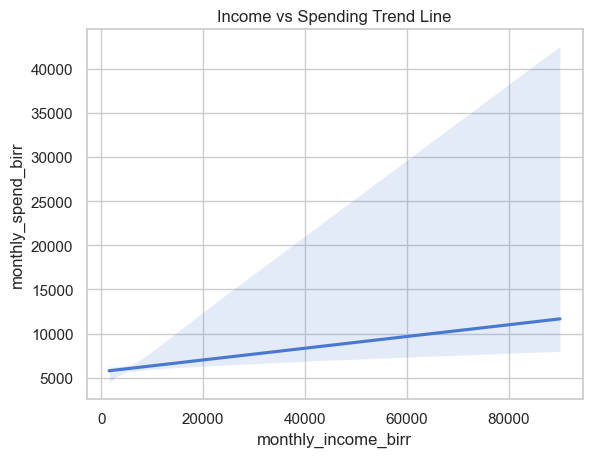

<Figure size 640x480 with 0 Axes>

In [2]:
# Enhancement: Regression Trend Line
sns.regplot(
    data=df,
    x='monthly_income_birr',
    y='monthly_spend_birr',
    scatter=False
)
plt.title('Income vs Spending Trend Line')
plt.show()
plt.savefig('../charts/11_Income vs Spending.png', dpi=150)

**Key Insight:** The trend line rises from approximately 6,000 Birr monthly spend at the lowest income levels to ~12,000 Birr at the 90,000 Birr income ceiling — a modest 2× increase across the full income range. The confidence band widens sharply beyond 20,000 Birr income, reflecting very few observations at higher income levels and low predictive reliability in that zone. This confirms the earlier correlation finding (r = 0.11 from the heatmap) — income explains only a small fraction of spending variance.

**Business Impact:** A revenue growth strategy built on attracting higher-income customers will yield limited spend uplift; the behavioral drivers — visit frequency and spend per visit — are stronger and more actionable levers.

**Recommendation:** Use visit frequency and average spend per visit as the primary customer value signals rather than income, and reserve income as a secondary filter only when layered with behavioral data.


In [ ]:
# Enhancement: Statistical Validation (ANOVA)
from scipy.stats import f_oneway

groups = [
    g['customer_value_score'].dropna()
    for _, g in df.groupby('education_level')
]

anova_result = f_oneway(*groups)
print(anova_result)

F_onewayResult(statistic=np.float64(96.11085094474213), pvalue=np.float64(1.8261139092920574e-60))


### Key Insight

A significant result (p < 0.05) confirms that customer value scores differ across education groups, validating education as a meaningful segmentation variable.

### Business Impact

Education-based segmentation can be confidently used for customer targeting and campaign planning.

### Recommendation

Include education level in customer segmentation and develop tailored loyalty and marketing strategies for each group.


# Executive Summary

## Project Overview

This analysis examines survey responses from ~500 customers across five Ethiopian regions — Addis Ababa, Oromia, Amhara, SNNPR, and Tigray — profiling demographics, spending behavior, product preferences, purchase channels, satisfaction, and customer value to support evidence-based commercial strategy.



## Top 5 Business Insights

**1. Visit Frequency — Not Income — Drives Revenue**
The correlation matrix confirms visits per month predicts both monthly spend (r = 0.80) and customer value score (r = 0.82), while monthly income shows near-zero correlation with both (r = 0.11 and r = 0.08). Behavioral data outperforms demographic targeting.

**2. Price Sensitivity Is the Dominant Customer Barrier**
"Price too high" accounts for ~202 of all challenge responses — more than double the second-ranked issue (poor product quality at ~86) and an estimated 40%+ of total reported challenges. Affordability friction is the single largest obstacle to conversion.

**3. Food & Groceries Leads Demand by a 2× Margin**
With ~163 respondents selecting food & groceries as their preferred category versus ~82 for home goods, the top category commands demand twice that of any alternative — making it the non-negotiable anchor of any inventory or promotional strategy.

**4. Physical Shop and Word of Mouth Control 69% of Customer Engagement**
Physical shop (42.6%) and word of mouth (26.6%) together account for 69.2% of purchase channels. Digital channels — mobile app (16.4%) and social media (14.4%) — are active but secondary, signaling early-stage digital adoption rather than a mature digital customer base.

**5. One in Five Customers Is at Churn Risk**
Satisfaction scores 1 and 2 combined represent ~109 respondents — approximately 22% of the sample. With score 3 as the mode (~245 respondents), the majority are neutrally satisfied and have no loyalty buffer against a single negative experience.



## Top 3 Strategic Recommendations

**1. Shift Targeting from Income to Behavioral Signals**
Replace income brackets in CRM logic with a visit-frequency and spend-per-visit composite score. The data confirms income does not predict who spends; behavior does.

**2. Formalize Word of Mouth into a Managed Referral Program**
26.6% of customers arrive through peer referral — an organic channel the business is not actively managing. A structured incentive program can amplify this at low cost before scaling digital investment.

**3. Address Price Sensitivity with Tiered Pricing**
With 40%+ of customers citing price as their top barrier, introduce a value bundle or entry-level tier targeted at the sub-10,000 Birr income majority, while maintaining premium positioning for government and private employee segments who spend 3–4× more per visit.



## Additional Analyses Recommended

| Analysis                                  | Business Value                                                                            |
| ----------------------------------------- | ----------------------------------------------------------------------------------------- |
| K-Means Customer Segmentation             | Build 3–4 actionable behavioral tiers using visit frequency, spend, and satisfaction      |
| High-Value Customer Profiling             | Isolate the top 20% by customer value score for priority retention investment             |
| Chi-Square: Channel vs Product Preference | Test whether channel choice and product preference are statistically linked               |
| Regional Opportunity Analysis             | Quantify revenue potential in Amhara, SNNPR, and Tigray using income and spend benchmarks |
| Satisfaction Driver Analysis              | Identify which demographic and behavioral variables predict scores 1–2                    |
